# Prototype

## Channel Model – Key Relations

$th(x) = gpc \left( 1 - \exp(-c Q(x) t_p) \right)$  

$Q(x) = Q_0 \exp(-x/x_s)$  

$x_s \propto \sqrt{T/p_A}$

In [1]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Channel Profile

In [2]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [3]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.01 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 100 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [4]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

model.pA = max(model.pA, 1e-3)
model.K = max(model.K, 1e-6)

In [5]:
import numpy as np
import pandas as pd

# ===== 설정 =====
N = 300
gpc_nominal = 1.2e-10

amp_ratio = 0.1        # 20% amplitude
period = 100            # 주기
noise_level = 0.05     # 5% noise

# ===== sinusoidal base =====
steps = np.arange(N)

gpc_base = gpc_nominal * (
    1 + amp_ratio * np.sin(2 * np.pi * steps / period)
)

# ===== noise =====
noise = 1 + noise_level * np.random.randn(N)

gpc_values = gpc_base * noise

# ===== 안정성 =====
gpc_values = np.clip(gpc_values, 1e-15, None)

# ===== 저장 =====
df = pd.DataFrame({
    "step": steps,
    "gpc": gpc_values
})

df.to_csv("gpc_data.csv", index=False)

print("gpc_data.csv 생성 완료")
print(df.head())

gpc_data.csv 생성 완료
   step           gpc
0     0  1.028309e-10
1     1  1.264755e-10
2     2  1.210321e-10
3     3  1.125531e-10
4     4  1.210752e-10


In [6]:
import pandas as pd

gpc_df = pd.read_csv("gpc_data.csv")

def get_gpc(k):
    if k < len(gpc_df):
        return gpc_df.iloc[k]["gpc"]
    else:
        return gpc_df.iloc[-1]["gpc"]

MPC violations: 0
Fixed violations: 0
MPC total: 76.53053081442717
Fixed total: 316.28160000000094


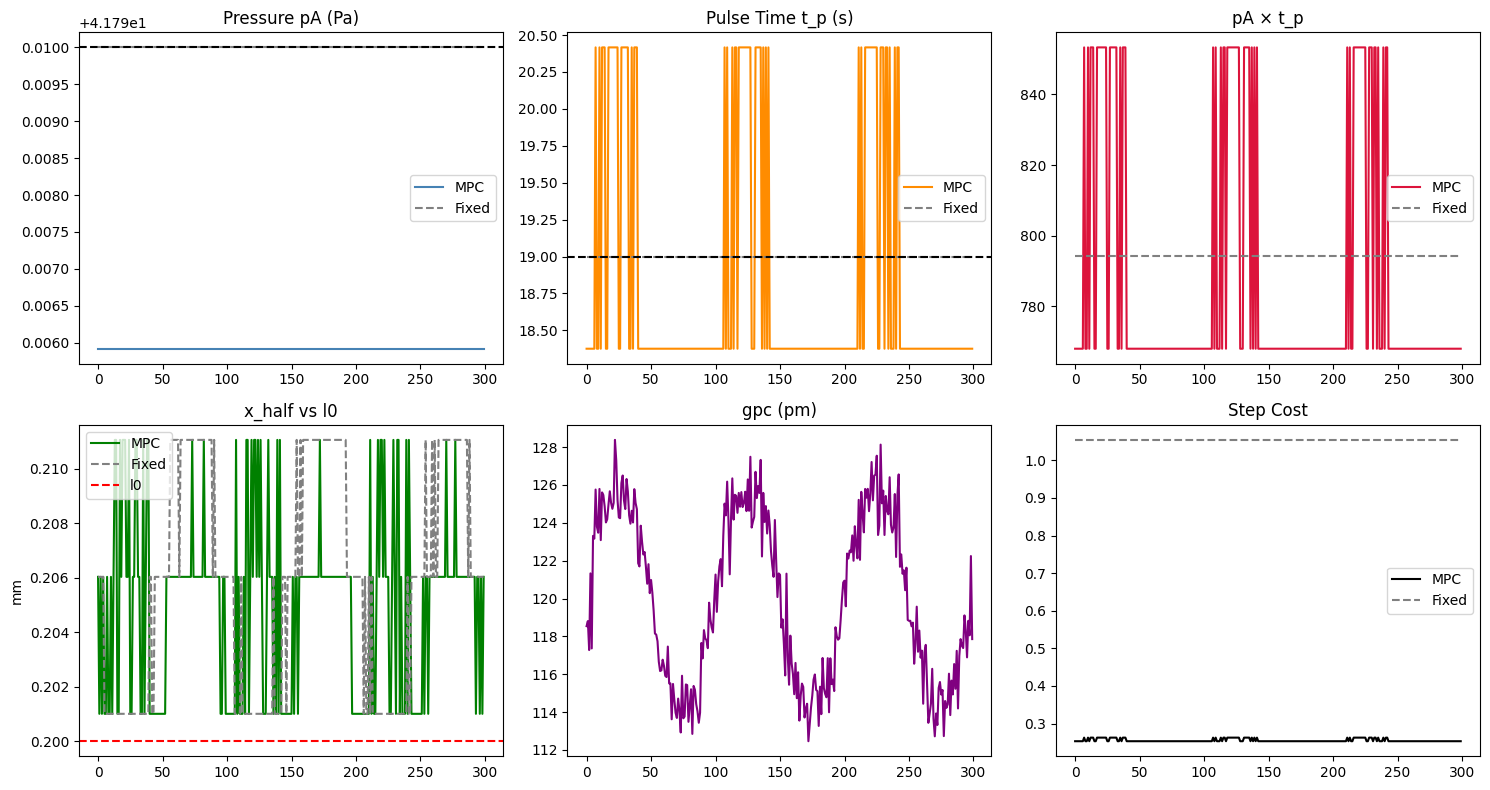

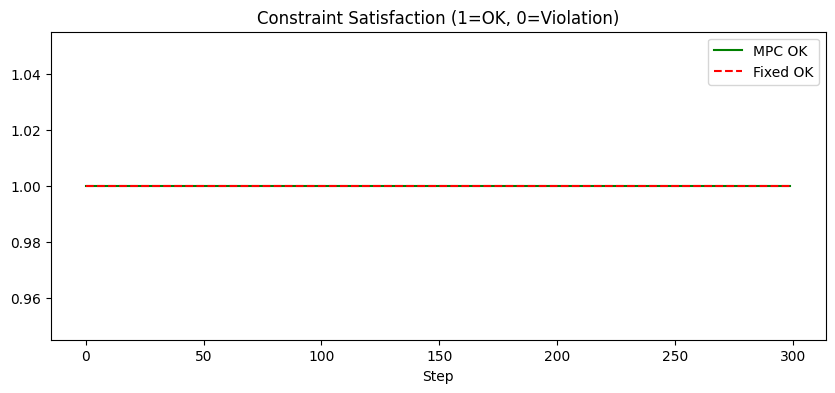

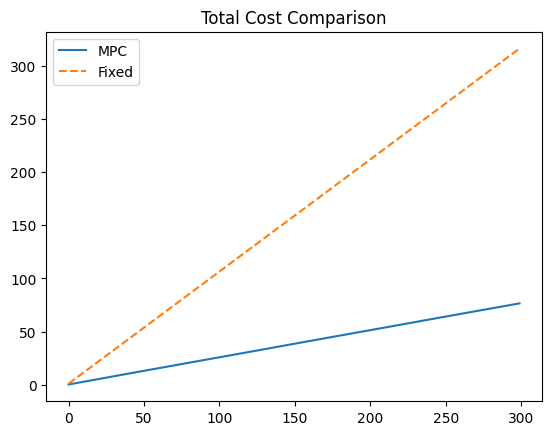

In [7]:
# ============================================================
# 0. import
# ============================================================
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# 1. gpc 생성 (sinusoidal + noise)
# ============================================================
def generate_gpc(N=300):
    gpc_nominal = 1.2e-10
    amp = 0.05
    period = 100
    noise_level = 0.01

    steps = np.arange(N)

    gpc_base = gpc_nominal * (
        1 + amp * np.sin(2*np.pi*steps/period)
    )

    noise = 1 + noise_level * np.random.randn(N)
    gpc = gpc_base * noise

    return np.clip(gpc, 1e-15, None)

gpc_data = generate_gpc()

def get_gpc(k):
    if k < len(gpc_data):
        return gpc_data[k]
    return gpc_data[-1]

# ============================================================
# 2. cost function
# ============================================================
def cost_function(pA, tp, pA_prev, tp_max):
    tp_n = tp / tp_max
    return (
        tp_n/2.5
        + tp_n * pA / (250*2.5)
        + pA/250
    )

# ============================================================
# 3. 모델
# ============================================================
class channelModelMPC(channelModel):

    def approx(self, x, last_theta):
        D = (self.pA * self.Deff * self.H /
             (self.q * k * self.T *
              (1 - np.log(self.K * self.pA + 1) / (self.K * self.pA))))

        xs = np.sqrt(max(D * self.t_p, 1e-20))

        pA_profile = self.pA * (1 - x / xs)
        pA_profile = np.clip(pA_profile, 0, None)

        theta = (self.K * pA_profile) / (1 + self.K * pA_profile)
        next_theta = last_theta + theta
        thickness = self.gpc * next_theta

        return thickness, next_theta, {'pA': pA_profile}

    def prepare(self):
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        self.calc_hydro_diameter()
        self.calc_Deff()

# ============================================================
# 4. x_half
# ============================================================
def find_x_half(pA_profile, x):
    half = 0.5 * pA_profile[0]
    idx = np.where(pA_profile <= half)[0]

    if len(idx) == 0:
        return x[-1]

    i = idx[0]
    if i == 0:
        return x[0]

    return x[i-1]

# ============================================================
# 5. evaluate
# ============================================================
def evaluate(pA, tp, model, x, last_theta):
    m = copy.copy(model)
    m.pA = pA
    m.t_p = tp
    m.prepare()

    thickness, next_theta, info = m.approx(x, last_theta)
    x_half = find_x_half(info['pA'], x)

    return thickness, next_theta, x_half

# ============================================================
# 6. MPC step (grid + refine)
# ============================================================
def mpc_step(model, x, last_theta, l_0, pA_bounds, tp_bounds):

    pA_prev = model.pA
    tp_max = tp_bounds[1]

    def J(p, t):
        return cost_function(p, t, pA_prev, tp_max)

    best = None
    best_cost = np.inf
    best_xh = -np.inf
    best_xh_u = None

    P_grid = np.linspace(*pA_bounds, 50)
    T_grid = np.linspace(*tp_bounds, 50)

    for P in P_grid:
        for T in T_grid:
            _, _, xh = evaluate(P, T, model, x, last_theta)

            if xh >= l_0:
                cost = J(P, T)
                if cost < best_cost:
                    best_cost = cost
                    best = (P, T)

            if xh > best_xh:
                best_xh = xh
                best_xh_u = (P, T)

    if best is not None:
        return best[0], best[1]

    # infeasible fallback
    print("[INFEASIBLE] using max x_half")
    return best_xh_u[0], best_xh_u[1]

# ============================================================
# 7. MPC run
# ============================================================
def run_mpc(x, steps, l_0, T_fixed, pA_bounds, tp_bounds):

    model = channelModelMPC()
    model.T = T_fixed
    model.pA = np.mean(pA_bounds)
    model.t_p = np.mean(tp_bounds)

    last_theta = np.zeros_like(x)
    hist = []
    total = 0

    for k in range(steps):

        model.gpc = get_gpc(k)

        pA, tp = mpc_step(model, x, last_theta, l_0, pA_bounds, tp_bounds)

        _, last_theta, xh = evaluate(pA, tp, model, x, last_theta)

        cost = cost_function(pA, tp, model.pA, tp_bounds[1])
        total += cost

        ok = xh >= l_0

        hist.append({
            'step':k,
            'pA':pA,
            't_p':tp,
            'gpc':model.gpc,
            'x_half':xh,
            'ok':ok,
            'cost':cost,
            'total':total
        })

        model.pA = pA
        model.t_p = tp

    return pd.DataFrame(hist)

# ============================================================
# 8. fixed
# ============================================================
def run_fixed(x, steps, l_0, T_fixed, pA, tp):

    model = channelModelMPC()
    model.T = T_fixed
    model.pA = pA
    model.t_p = tp

    last_theta = np.zeros_like(x)
    hist = []
    total = 0

    for k in range(steps):

        model.gpc = get_gpc(k)

        _, last_theta, xh = evaluate(pA, tp, model, x, last_theta)

        cost = cost_function(pA, tp, pA, 10)
        total += cost

        hist.append({
            'step':k,
            'pA':pA,
            't_p':tp,
            'gpc':model.gpc,
            'x_half':xh,
            'ok':xh >= l_0,
            'cost':cost,
            'total':total
        })

    return pd.DataFrame(hist)

# ============================================================
# (기존 코드 그대로 유지)
# 👉 run_mpc / run_fixed까지 동일
# ============================================================

# ============================================================
# 9. 실행
# ============================================================
x = np.linspace(0,1e-3,200)
l_0 = 0.2e-3
T_fixed = 673

mpc_df = run_mpc(x, 300, l_0, T_fixed, (1,2000), (0.01,100))
fix_df = run_fixed(x, 300, l_0, T_fixed, 41.8, 19)

# ============================================================
# 10. 비교 출력
# ============================================================
print("MPC violations:", (~mpc_df['ok']).sum())
print("Fixed violations:", (~fix_df['ok']).sum())

print("MPC total:", mpc_df['total'].iloc[-1])
print("Fixed total:", fix_df['total'].iloc[-1])

# ============================================================
# 🔥 11. 상태 비교 플롯 (핵심)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

steps_arr = mpc_df['step']

# 1️⃣ pA
axes[0,0].plot(steps_arr, mpc_df['pA'], label="MPC", color='steelblue')
axes[0,0].plot(steps_arr, fix_df['pA'], '--', label="Fixed", color='gray')
axes[0,0].axhline(41.8, linestyle='--', color='black')
axes[0,0].set_title("Pressure pA (Pa)")
axes[0,0].legend()

# 2️⃣ t_p
axes[0,1].plot(steps_arr, mpc_df['t_p'], label="MPC", color='darkorange')
axes[0,1].plot(steps_arr, fix_df['t_p'], '--', label="Fixed", color='gray')
axes[0,1].axhline(19, linestyle='--', color='black')
axes[0,1].set_title("Pulse Time t_p (s)")
axes[0,1].legend()

# 3️⃣ pA × t_p
axes[0,2].plot(steps_arr, mpc_df['pA'] * mpc_df['t_p'],
               label="MPC", color='crimson')
axes[0,2].plot(steps_arr, fix_df['pA'] * fix_df['t_p'],
               '--', label="Fixed", color='gray')
axes[0,2].set_title("pA × t_p")
axes[0,2].legend()

# 4️⃣ x_half vs l0 (🔥 제일 중요)
axes[1,0].plot(steps_arr, mpc_df['x_half']*1e3,
               label="MPC", color='green')
axes[1,0].plot(steps_arr, fix_df['x_half']*1e3,
               '--', label="Fixed", color='gray')

axes[1,0].axhline(l_0*1e3, linestyle='--', color='red', label="l0")

axes[1,0].set_title("x_half vs l0")
axes[1,0].set_ylabel("mm")
axes[1,0].legend()

# 5️⃣ gpc
axes[1,1].plot(steps_arr, mpc_df['gpc']*1e12, color='purple')
axes[1,1].set_title("gpc (pm)")

# 6️⃣ step cost 비교
axes[1,2].plot(steps_arr, mpc_df['cost'],
               label="MPC", color='black')
axes[1,2].plot(steps_arr, fix_df['cost'],
               '--', label="Fixed", color='gray')
axes[1,2].set_title("Step Cost")
axes[1,2].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 🔥 12. constraint 만족 여부 (진짜 중요)
# ============================================================
plt.figure(figsize=(10,4))

plt.plot(steps_arr, mpc_df['ok'].astype(int),
         label="MPC OK", color='green')

plt.plot(steps_arr, fix_df['ok'].astype(int),
         '--', label="Fixed OK", color='red')

plt.title("Constraint Satisfaction (1=OK, 0=Violation)")
plt.xlabel("Step")
plt.legend()

plt.show()

# ============================================================
# 🔥 13. cumulative cost
# ============================================================
plt.figure()

plt.plot(steps_arr, mpc_df['total'], label="MPC")
plt.plot(steps_arr, fix_df['total'], '--', label="Fixed")

plt.title("Total Cost Comparison")
plt.legend()

plt.show()